In [1]:
from gpaw.new.ase_interface import GPAW
# from ase import Atoms
import numpy as np
from gpaw import FermiDirac
from ase.visualize import view
from ase.io import read

## Primitive cell

In [2]:
primitive = read("1MnI2-1.cif")
name = primitive.get_chemical_formula(mode='metal')

In [3]:
from gpaw.utilities.dos import print_projectors
 
print("=== Projectors for Mn ===")
print_projectors('Mn')   # shows lines like:  0  s, 1  p, 2  d, ...
print()
print("=== Projectors for I  ===")
print_projectors('I')
print()


=== Projectors for Mn ===
 i n l m
--------
 0 3 s_1
 1 4 s_1
 2 3 p_y
 3 3 p_z
 4 3 p_x
 5 4 p_y
 6 4 p_z
 7 4 p_x
 8 3 d_xy
 9 3 d_yz
10 3 d_3z^2-r^2
11 3 d_xz
12 3 d_x^2-y^2
13 * d_xy
14 * d_yz
15 * d_3z^2-r^2
16 * d_xz
17 * d_x^2-y^2

=== Projectors for I  ===
 i n l m
--------
 0 5 s_1
 1 5 p_y
 2 5 p_z
 3 5 p_x
 4 * s_1
 5 * p_y
 6 * p_z
 7 * p_x
 8 * d_xy
 9 * d_yz
10 * d_3z^2-r^2
11 * d_xz
12 * d_x^2-y^2



## Create magnetic supercell

In [30]:
#Define transformation matrix from primitive to magnetic cell
P = np.array([
    [2, 1, 0],
    [-1, 1, 0],
    [0, 0, 1]
])
#defines supercell basis as linear combination of primitive basis

# So Supercell A1 = 2a_1+1a_2
#A2=-a1+a2

In [31]:
from ase.build import make_supercell

supercell = make_supercell(primitive, P)

## Creating spiral magnetic moments

The magnetization density satisfies:
$$\mathbf{m(r+r_i)} = R_{\hat n}(\mathbf{q\cdot r_i})\mathbf{m(r)}$$
(see the paper).
Take the reference spin $m_0=(0,m,0)$. Then:

$$
\mathbf{m(r+r_i)} = \begin{pmatrix} \cos(\varphi) & -\sin(\varphi)\\ \sin(\varphi) & \cos(\varphi) \end{pmatrix}
\begin{pmatrix} 0 \\ m \end{pmatrix} = \begin{pmatrix} -m\sin(\varphi) \\ m\cos(\varphi) \end{pmatrix}
$$
With $\varphi = \mathbf{q\cdot r_i}$

So, we can calculate the other spins easily based on a reference spin in the y-direction. The spiral does not rotate in the z-direction, thus the 2x2 above.

We could have chosen the reference spin to point in any direction. This physically changes nothing. I chose the y-direction only so the spins align exactly in the way we see them in Fig 1 of the paper.

**Important note about chirality:**

Currently we have a counter-clockwise rotating spiral in the above. If I read the paper Fig 1 d correctly, they have a clockwise rotating spiral. This corresponds to changing $\mathbf{Q} \rightarrow \mathbf{-Q}$.

When there is no SOC (or other symmetry breaking terms), these two options should be identical. SOC breaks the symmetry though, and the chiralities might yield different results.

Below, I include two options. The first is reference spin in x, counterclockwise rotation.

If we wish to Match Fig 1d visually completely, then I found that a reference spin in the y-direction and clock-wise rotating spiral (see -Q in the code) will do the trick.


**Choosing reference spin in the x-direction, counterclockwise rotating spiral**

In [32]:
# m = 4.5
# magmoms = np.zeros((len(supercell), 3))


# A = primitive.cell[:2, :2] #extracts the 2D lattice vectors from the PRIMITIVE CELL. It is a 2x2 matrix.
# A_inv = np.linalg.inv(A.T) #Invert the above, constructs a mapping from cartesian to lattice coordinates. Transposed since ASE stores lattice vectors as rows, we need them as columns.
#                             #This gives \vec{n}=A^{-1}\vec{r}, where r is cartesian position, n is coordinates in lattice basis
# Q = np.array([1/3, 1/3])    #Defines the magnetic ordering vector in reciprocal lattice coordinates.

# for i, atom in enumerate(supercell):
#     if atom.symbol != 'Mn':
#         continue

#     r_cart = atom.position[:2] #extracts the cartesian position of the Mn atom
#     n = A_inv @ r_cart         # Converts to lattice coordinates \vec{r}=n_1a_1+n_2a_2

#     phase = 2 * np.pi * np.dot(Q, n) #each lattice site gets a phase angle depending on its position (given via the lattice coordinates n)

#     magmoms[i] = [                   #Assigns a planar spin spiral
#         m * np.cos(phase),
#         m * np.sin(phase),
#         0.0
#     ]

# supercell.set_initial_magnetic_moments(magmoms)

In [33]:
# view(supercell)
# #In the GUI, go to View->show Magmoms. Also, View->repeat, 2 in x and y

**Choosing reference spin in the y-direction, clockwise rotating spiral**

Matches Fig 1d visually exactly.

In [34]:
m = 4.5
magmoms = np.zeros((len(supercell), 3))


A = primitive.cell[:2, :2] #extracts the 2D lattice vectors from the PRIMITIVE CELL. It is a 2x2 matrix.
A_inv = np.linalg.inv(A.T) #Invert the above, constructs a mapping from cartesian to lattice coordinates. Transposed since ASE stores lattice vectors as rows, we need them as columns.
                            #This gives \vec{n}=A^{-1}\vec{r}, where r is cartesian position, n is coordinates in lattice basis
Q = np.array([1/3, 1/3])    #Defines the magnetic ordering vector in reciprocal lattice coordinates.

for i, atom in enumerate(supercell):
    if atom.symbol != 'Mn':
        continue

    r_cart = atom.position[:2] #extracts the cartesian position of the Mn atom
    n = A_inv @ r_cart         # Converts to lattice coordinates \vec{r}=n_1a_1+n_2a_2

    phase = 2 * np.pi * np.dot(-Q, n) #each lattice site gets a phase angle depending on its position (given via the lattice coordinates n)
    #NOTE minus Q above for clockwise

    magmoms[i] = [                   #Assigns a planar spin spiral, note that m_0=(0,m,0) to get this.
        -m * np.sin(phase),
        m * np.cos(phase),
        0.0
    ]
supercell.set_initial_magnetic_moments(magmoms)

In [36]:
# view(supercell)
# #In the GUI, go to View->show Magmoms. Also, View->repeat, 2 in x and y

## GPAW calculator and SCF calc
Rough estimate for the notebook here.

In [37]:
# --- 4. Setup GPAW Calculator ---
# Article specifies: LDA functional, 600 eV cutoff.
# Symmetry must be off for non-collinear spirals.
# k-points: The magnetic BZ is smaller. 

calc = GPAW(
    mode={'name':'pw',
          'ecut':100},          # 600 eV cutoff in per paper. Rough first guess
    xc='LDA',                   # Paper explicitly uses LDA 
    mixer={'backend': 'pulay',              #This was used to mimic https://gpaw.readthedocs.io/tutorialsexercises/magnetic/spinspiral/spinspiral.html#spin-spiral-calculations
                       'beta': 0.05,
                       'method': 'sum',
                       'nmaxold': 5,
                       'weight': 100},
    kpts={'size':(3,3,1), 'gamma':True},       # Adjusted for the rhombus supercell
    symmetry='off',        # Crucial for spiral
    magmoms=magmoms,       # Enforce non-collinear start
    spinpol=True,          # Needed for non-collinear
    occupations=FermiDirac(0.01),
    txt=name+'_rough_work.txt',
    parallel={'domain': 1, 'band': 1},
    maxiter=50,
    soc = True,
)

calc.verbosity=1

supercell.calc = calc

### Run SCF calc

In [38]:
# --- 5. Run Calculation ---
print("Running SCF for magnetic supercell...")
energy = supercell.get_potential_energy()
calc.write(name+'_rough_work.gpw')

Running SCF for magnetic supercell...


In [39]:
#Checking convergence and magnetic moments
energy = supercell.get_potential_energy()
print('energy=',energy) #check for divergence. If it diverges, something wrong in the setup
print('')
#Magmoms
print('Local magnetic moments = ', supercell.get_magnetic_moments())
#We want three Mn moments, roughly 120 degrees apart, magnitude around 3-5 µB
print('')
#Total M
print('Total magnetic moment=', supercell.get_magnetic_moment())
#Should be 0. If they align ferromagnetically, phase may be incorrectly assigned

#Encountering some strangeness. Printing all arrays.
# print('All arrays')
# print(supercell.arrays)

energy= 116.74918727977654

Local magnetic moments =  [-5.08237602e-04 -8.68209728e-05 -3.60950186e-04 -2.22233208e-04
 -8.14296403e-05  1.78378503e-04 -2.22233208e-04 -8.68209728e-05
  1.78378503e-04]

Total magnetic moment= -0.0016830171320861384


In [40]:
# THIS SHOWS THE LOCAL MAGNETIC MOMENTS AFTER THE CALCULATION
calc.get_non_collinear_magnetic_moments()

array([[-4.42128948e-14,  3.47148489e+00, -5.08237602e-04],
       [ 1.52688708e-03, -8.20665397e-04, -8.68209728e-05],
       [ 8.05929658e-16, -4.23518653e-05, -3.60950186e-04],
       [ 3.00632060e+00, -1.73611699e+00, -2.22233208e-04],
       [ 7.54514890e-15,  1.66755274e-03, -8.14296403e-05],
       [-4.49060931e-05,  4.18203372e-05,  1.78378503e-04],
       [-3.00632060e+00, -1.73611699e+00, -2.22233208e-04],
       [-1.52688708e-03, -8.20665397e-04, -8.68209728e-05],
       [ 4.49060931e-05,  4.18203372e-05,  1.78378503e-04]])

## Loading the GPW file
Instead of running the SCF code every time

In [41]:
calc2 = GPAW(name+'_rough_work.gpw')
atoms = calc2.get_atoms()

In [55]:
# view(atoms)

As seen above, the "Atoms" object isn't updated with the resulting spin structure from the GPAW calculation.

There is an issue with the ASE GUI when there is a calculator attached to the object. The stuff below is just to view the resulting structure after the calculation

In [42]:
atoms2 = calc2.get_atoms()
print('local moments after calc')
print(calc2.get_non_collinear_magnetic_moments()) #Show the calculated local moments)

atoms2.arrays['magmoms'] = calc2.get_non_collinear_magnetic_moments() #Forcing the Atoms magmoms to equal the calculated ones
atoms2.calc = None

local moments after calc
[[-4.42128948e-14  3.47148489e+00 -5.08237602e-04]
 [ 1.52688708e-03 -8.20665397e-04 -8.68209728e-05]
 [ 8.05929658e-16 -4.23518653e-05 -3.60950186e-04]
 [ 3.00632060e+00 -1.73611699e+00 -2.22233208e-04]
 [ 7.54514890e-15  1.66755274e-03 -8.14296403e-05]
 [-4.49060931e-05  4.18203372e-05  1.78378503e-04]
 [-3.00632060e+00 -1.73611699e+00 -2.22233208e-04]
 [-1.52688708e-03 -8.20665397e-04 -8.68209728e-05]
 [ 4.49060931e-05  4.18203372e-05  1.78378503e-04]]


In [43]:
# view(atoms2)

The above visually shows that our spin spiral structure is still present

## Bandstructure

We are working in the magnetic supercell, so I guess(?) we will compute bands in the magnetic Brillouin Zone.

In [44]:
from ase.dft.kpoints import bandpath

In [46]:
M = [0.5, 0.0, 0.0]
minus_M = [-0.5, 0.0, 0.0]
Gamma = [0.0, 0.0, 0.0]

kpts = np.array([
    minus_M,
    Gamma,
    M
])

path = bandpath(kpts, supercell.cell, npoints=20)

In [48]:
#Non SCF band calc
calc = GPAW(name+'_rough_work.gpw').fixed_density(
    kpts=path,
    symmetry='off'
)


Diagonalizing LCAO Hamiltonian
Converting LCAO to grid
convergence criteria:
- Maximum integral of absolute [eigenst]ate change: 4e-08 eV^2 / valence electron
maximum number of iterations: 50

     iter     time        total  log10-change:
                         energy   eigst   dens
iter:   1 15:40:10                               +0.0,-0.0,-0.0
iter:   2 15:40:24                -0.73          +0.0,-0.0,-0.0
iter:   3 15:40:38                -1.21          +0.0,-0.0,-0.0
iter:   4 15:40:52                -1.61          +0.0,-0.0,-0.0
iter:   5 15:41:06                -1.97          +0.0,-0.0,-0.0
iter:   6 15:41:20                -2.31          +0.0,-0.0,-0.0
iter:   7 15:41:34                -2.65          +0.0,-0.0,-0.0
iter:   8 15:41:48                -2.97          +0.0,-0.0,-0.0
iter:   9 15:42:02                -3.29          +0.0,-0.0,-0.0
iter:  10 15:42:16                -3.59          +0.0,-0.0,-0.0
iter:  11 15:42:30                -3.88          +0.0,-0.0,-0.0
iter:  1

In [ ]:
ef = calc.get_fermi_level()

# Get eigenvalues for each k-point
e_kn = np.array([calc.get_eigenvalues(kpt=k) for k in range(len(calc.get_ibz_k_points()))])
e_kn -=ef


In [51]:
bs = calc.band_structure()

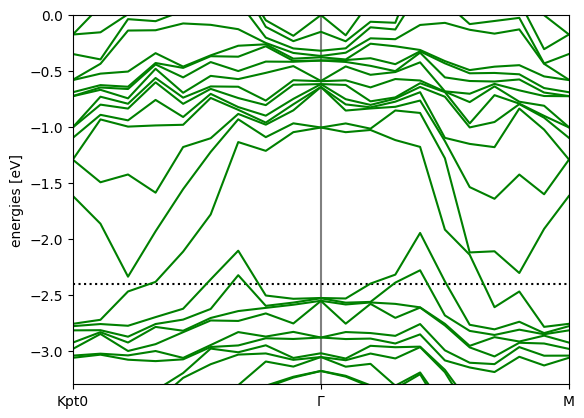

In [55]:
import matplotlib.pyplot as plt

bs.plot( emin=-3.3, emax=0)
plt.savefig(name+'_rough_work_nocolor.png')   
plt.savefig(name+'_rough_work_nocolor.pdf')   
# plt.show()